In [96]:
import os 
import polars as pl

In [97]:
data_path = "raw_data"

items = pl.scan_parquet(os.path.join(data_path, "sales_pers.item_chunk_0.parquet"))

In [98]:
items.collect().null_count()

p_id,item_id,price,category_l1_id,category_l1,category_l2_id,category_l2,category_l3_id,category_l3,category_id,category,description,brand,manufacturer,creation_timestamp,is_deleted,created_date,updated_date,sync_status_id,last_sync_date,sync_error_message,image_url,gender_target,age_group,item_type,gp,weight,color,size,origin,volume,material,sale_status,description_new
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,786,786,27332,0,0,0,0,0,27332,0,0,0,0,0,0,5015


In [99]:
items = items.drop(["sync_error_message", "weight", "description_new", "sync_status_id", "last_sync_date"])

In [100]:
items.collect().null_count()

p_id,item_id,price,category_l1_id,category_l1,category_l2_id,category_l2,category_l3_id,category_l3,category_id,category,description,brand,manufacturer,creation_timestamp,is_deleted,created_date,updated_date,image_url,gender_target,age_group,item_type,gp,color,size,origin,volume,material,sale_status
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [101]:
items.schema

C:\Users\USER\AppData\Local\Temp\ipykernel_21580\681984112.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  items.schema


Schema([('p_id', Int32),
        ('item_id', String),
        ('price', Decimal(precision=38, scale=4)),
        ('category_l1_id', Int32),
        ('category_l1', String),
        ('category_l2_id', Int32),
        ('category_l2', String),
        ('category_l3_id', Int32),
        ('category_l3', String),
        ('category_id', Int32),
        ('category', String),
        ('description', String),
        ('brand', String),
        ('manufacturer', String),
        ('creation_timestamp', Int64),
        ('is_deleted', Boolean),
        ('created_date', Datetime(time_unit='us', time_zone=None)),
        ('updated_date', Datetime(time_unit='us', time_zone=None)),
        ('image_url', String),
        ('gender_target', String),
        ('age_group', String),
        ('item_type', String),
        ('gp', Decimal(precision=38, scale=4)),
        ('color', String),
        ('size', String),
        ('origin', String),
        ('volume', String),
        ('material', String),
        ('sa

In [102]:
import matplotlib.pyplot as plt 
import seaborn as sns
import polars.selectors as cs
import math 

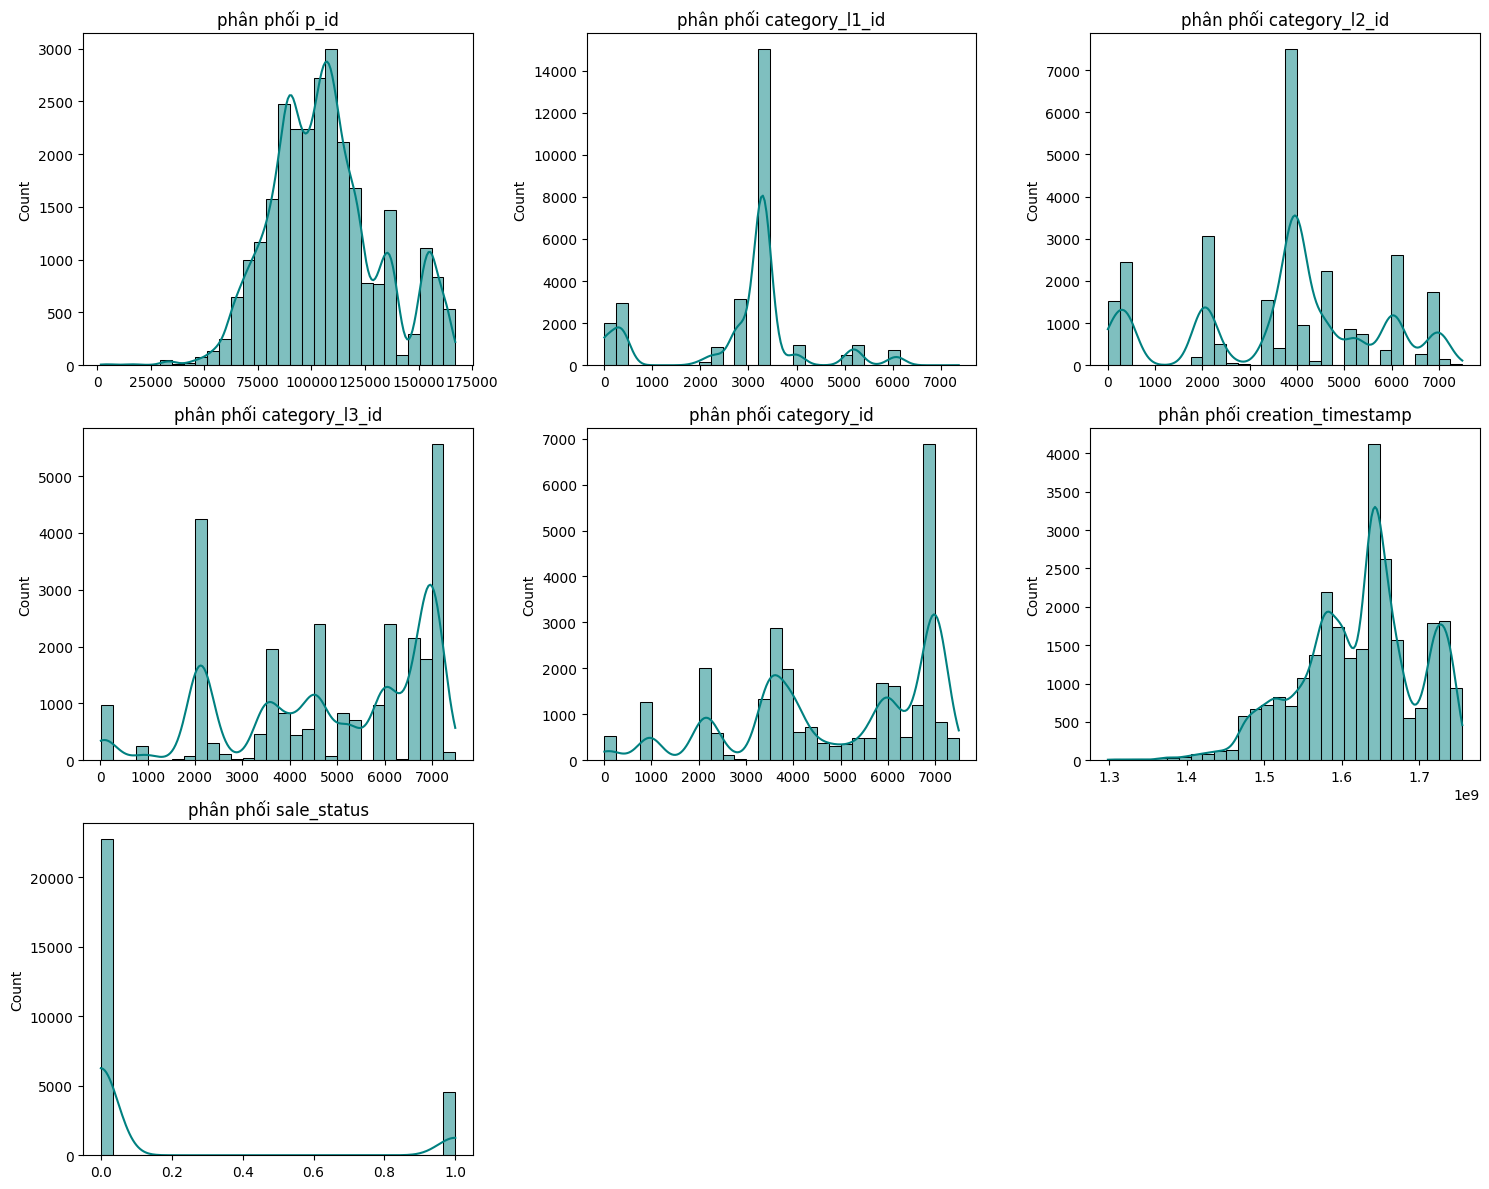

In [103]:
clean_items_nums = items.select(cs.integer()).collect()

cols = clean_items_nums.columns
n_cols = len(cols)

n_layout_cols = min(3,n_cols)
n_layout_rows = math.ceil(n_cols / n_layout_cols)

plt.figure(figsize=(5*n_layout_cols, 4*n_layout_rows))

for idx, col in enumerate(cols,1):
  plt.subplot(n_layout_rows, n_layout_cols, idx)
  sns.histplot(clean_items_nums, x=col, kde=True, bins=30, color = "teal")
  plt.title(f"phân phối {col}")
  plt.xlabel("")

plt.tight_layout()
plt.show()

In [104]:
items = items.with_columns(
    pl.col("sale_status").cast(pl.Boolean)
)

In [105]:
items.schema

C:\Users\USER\AppData\Local\Temp\ipykernel_21580\681984112.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  items.schema


Schema([('p_id', Int32),
        ('item_id', String),
        ('price', Decimal(precision=38, scale=4)),
        ('category_l1_id', Int32),
        ('category_l1', String),
        ('category_l2_id', Int32),
        ('category_l2', String),
        ('category_l3_id', Int32),
        ('category_l3', String),
        ('category_id', Int32),
        ('category', String),
        ('description', String),
        ('brand', String),
        ('manufacturer', String),
        ('creation_timestamp', Int64),
        ('is_deleted', Boolean),
        ('created_date', Datetime(time_unit='us', time_zone=None)),
        ('updated_date', Datetime(time_unit='us', time_zone=None)),
        ('image_url', String),
        ('gender_target', String),
        ('age_group', String),
        ('item_type', String),
        ('gp', Decimal(precision=38, scale=4)),
        ('color', String),
        ('size', String),
        ('origin', String),
        ('volume', String),
        ('material', String),
        ('sa

In [106]:
items_string = items.select(cs.string())

##items_string = items_cate.drop(["item_id", "category_l1", "category_l2", "category_l3", "description", "image_url"])
with pl.Config(tbl_cols=-1, tbl_width_chars=1000):  

    print(items_string.collect())

shape: (27_332, 17)
┌───────────────┬────────────────┬────────────────────┬───────────────────────────────┬───────────────────────┬─────────────────────────────────┬──────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────────┬────────────────┬─────────────────────────────────┐
│ item_id       ┆ category_l1    ┆ category_l2        ┆ category_l3                   ┆ category              ┆ description                     ┆ brand            ┆ manufacturer   ┆ image_url      ┆ gender_target  ┆ age_group      ┆ item_type      ┆ color          ┆ size           ┆ origin             ┆ volume         ┆ material                        │
│ ---           ┆ ---            ┆ ---                ┆ ---                           ┆ ---                   ┆ ---                             ┆ ---              ┆ ---            ┆ ---            ┆ ---            ┆ ---            ┆ ---            ┆ ---            ┆ -

In [107]:
with pl.Config(tbl_cols=-1, tbl_width_chars=1000):  
    print(
        items_string.select(
            cs.string().str.to_lowercase().is_in(["nan", "null", "none"]).sum()
        ).collect()
    )

shape: (1, 17)
┌─────────┬─────────────┬─────────────┬─────────────┬──────────┬─────────────┬───────┬──────────────┬───────────┬───────────────┬───────────┬───────────┬───────┬──────┬────────┬────────┬──────────┐
│ item_id ┆ category_l1 ┆ category_l2 ┆ category_l3 ┆ category ┆ description ┆ brand ┆ manufacturer ┆ image_url ┆ gender_target ┆ age_group ┆ item_type ┆ color ┆ size ┆ origin ┆ volume ┆ material │
│ ---     ┆ ---         ┆ ---         ┆ ---         ┆ ---      ┆ ---         ┆ ---   ┆ ---          ┆ ---       ┆ ---           ┆ ---       ┆ ---       ┆ ---   ┆ ---  ┆ ---    ┆ ---    ┆ ---      │
│ u32     ┆ u32         ┆ u32         ┆ u32         ┆ u32      ┆ u32         ┆ u32   ┆ u32          ┆ u32       ┆ u32           ┆ u32       ┆ u32       ┆ u32   ┆ u32  ┆ u32    ┆ u32    ┆ u32      │
╞═════════╪═════════════╪═════════════╪═════════════╪══════════╪═════════════╪═══════╪══════════════╪═══════════╪═══════════════╪═══════════╪═══════════╪═══════╪══════╪════════╪════════╪═══════

In [108]:
print(
    items_string.filter(
        pl.col("category_l3").str.to_lowercase().is_in(["nan", "null", "none"])
    )
    .select("category_l3", "category")
    .collect()
)

shape: (20, 2)
┌─────────────┬────────────┐
│ category_l3 ┆ category   │
│ ---         ┆ ---        │
│ str         ┆ str        │
╞═════════════╪════════════╡
│ NAN         ┆ NAN Step 2 │
│ NAN         ┆ NAN Step 3 │
│ NAN         ┆ NAN Step 1 │
│ NAN         ┆ NAN Step 4 │
│ NAN         ┆ NAN Step 2 │
│ …           ┆ …          │
│ NAN         ┆ NAN Step 4 │
│ NAN         ┆ NAN Step 3 │
│ NAN         ┆ NAN Step 4 │
│ NAN         ┆ NAN Step 3 │
│ NAN         ┆ NAN Step 4 │
└─────────────┴────────────┘


In [109]:
print(
    items_string.filter(
        pl.col("category").str.to_lowercase().is_in(["nan", "null", "none"])
    )
    .select("category_l3", "category")
    .collect()
)

shape: (8, 2)
┌─────────────┬──────────┐
│ category_l3 ┆ category │
│ ---         ┆ ---      │
│ str         ┆ str      │
╞═════════════╪══════════╡
│ Nestle      ┆ Nan      │
│ Nestle      ┆ Nan      │
│ Nestle      ┆ Nan      │
│ Nestle      ┆ Nan      │
│ Nestle      ┆ Nan      │
│ Nestle      ┆ Nan      │
│ Nestle      ┆ Nan      │
│ Nestle      ┆ Nan      │
└─────────────┴──────────┘


In [110]:
with pl.Config(tbl_cols=-1, tbl_width_chars=1000):
    print(
        items_string.select(
            (cs.string().str.strip_chars().str.to_lowercase() == "không xác định").sum()
        ).collect()
    )

shape: (1, 17)
┌─────────┬─────────────┬─────────────┬─────────────┬──────────┬─────────────┬───────┬──────────────┬───────────┬───────────────┬───────────┬───────────┬───────┬───────┬────────┬────────┬──────────┐
│ item_id ┆ category_l1 ┆ category_l2 ┆ category_l3 ┆ category ┆ description ┆ brand ┆ manufacturer ┆ image_url ┆ gender_target ┆ age_group ┆ item_type ┆ color ┆ size  ┆ origin ┆ volume ┆ material │
│ ---     ┆ ---         ┆ ---         ┆ ---         ┆ ---      ┆ ---         ┆ ---   ┆ ---          ┆ ---       ┆ ---           ┆ ---       ┆ ---       ┆ ---   ┆ ---   ┆ ---    ┆ ---    ┆ ---      │
│ u32     ┆ u32         ┆ u32         ┆ u32         ┆ u32      ┆ u32         ┆ u32   ┆ u32          ┆ u32       ┆ u32           ┆ u32       ┆ u32       ┆ u32   ┆ u32   ┆ u32    ┆ u32    ┆ u32      │
╞═════════╪═════════════╪═════════════╪═════════════╪══════════╪═════════════╪═══════╪══════════════╪═══════════╪═══════════════╪═══════════╪═══════════╪═══════╪═══════╪════════╪════════╪══

In [111]:
print(items.collect().shape)

(27332, 29)


In [112]:
items_string = items_string.drop(["manufacturer", "image_url", "volume", "material"])
items = items.drop(["manufacturer", "image_url", "volume", "material"])

In [113]:
with pl.Config(tbl_cols=-1, tbl_width_chars=1000):
    print(
        items_string.select(
            (cs.string().str.strip_chars().str.to_lowercase() == "không xác định").sum()
        ).collect()
    )

shape: (1, 13)
┌─────────┬─────────────┬─────────────┬─────────────┬──────────┬─────────────┬───────┬───────────────┬───────────┬───────────┬───────┬───────┬────────┐
│ item_id ┆ category_l1 ┆ category_l2 ┆ category_l3 ┆ category ┆ description ┆ brand ┆ gender_target ┆ age_group ┆ item_type ┆ color ┆ size  ┆ origin │
│ ---     ┆ ---         ┆ ---         ┆ ---         ┆ ---      ┆ ---         ┆ ---   ┆ ---           ┆ ---       ┆ ---       ┆ ---   ┆ ---   ┆ ---    │
│ u32     ┆ u32         ┆ u32         ┆ u32         ┆ u32      ┆ u32         ┆ u32   ┆ u32           ┆ u32       ┆ u32       ┆ u32   ┆ u32   ┆ u32    │
╞═════════╪═════════════╪═════════════╪═════════════╪══════════╪═════════════╪═══════╪═══════════════╪═══════════╪═══════════╪═══════╪═══════╪════════╡
│ 0       ┆ 0           ┆ 0           ┆ 0           ┆ 0        ┆ 18629       ┆ 5480  ┆ 18038         ┆ 15812     ┆ 9820      ┆ 26608 ┆ 25108 ┆ 22627  │
└─────────┴─────────────┴─────────────┴─────────────┴──────────┴─────────

# checkpoint xem mối quan hệ giữa các cột còn thiếu để điền khuyết cho nhau nếu có thể

đang giữ description, gender_target, item_type, color, size, origin (quốc gia)

In [114]:
with pl.Config(tbl_cols=-1, tbl_rows=-1, tbl_width_chars=1000):
    print(
        items_string.filter(
            # Điều kiện mô tả
            pl.col("category_l2").is_not_null()
            & (pl.col("category_l2").str.strip_chars().str.to_lowercase() != "không xác định")
            # Thêm điều kiện: item_type khác null và khác "không xác định"
            & pl.col("age_group").is_not_null()
            & (pl.col("age_group").str.strip_chars().str.to_lowercase() == "không xác định")
        )
        .select("age_group", "category_l2")
        .collect()
    )

shape: (15_812, 2)
┌────────────────┬──────────────────────────────┐
│ age_group      ┆ category_l2                  │
│ ---            ┆ ---                          │
│ str            ┆ str                          │
╞════════════════╪══════════════════════════════╡
│ Không xác định ┆ Bình sữa, phụ kiện           │
│ Không xác định ┆ 0-1Y                         │
│ Không xác định ┆ Merries                      │
│ Không xác định ┆ Merries                      │
│ Không xác định ┆ Cơ cấu hàng cũ               │
│ Không xác định ┆ 0-1Y                         │
│ Không xác định ┆ Huggies                      │
│ Không xác định ┆ Cơ cấu hàng cũ               │
│ Không xác định ┆ Moony                        │
│ Không xác định ┆ Cơ cấu hàng cũ               │
│ Không xác định ┆ 0-1Y                         │
│ Không xác định ┆ Bé ngủ                       │
│ Không xác định ┆ Gối                          │
│ Không xác định ┆ Đồ dùng vệ sinh              │
│ Không xác định ┆ Bé ngủ      

In [115]:
with pl.Config(tbl_cols=-1, tbl_width_chars=1000):
    print(
        items.select(
            (cs.string().str.strip_chars().str.to_lowercase() == "không xác định").sum()
        ).collect()
    )

shape: (1, 13)
┌─────────┬─────────────┬─────────────┬─────────────┬──────────┬─────────────┬───────┬───────────────┬───────────┬───────────┬───────┬───────┬────────┐
│ item_id ┆ category_l1 ┆ category_l2 ┆ category_l3 ┆ category ┆ description ┆ brand ┆ gender_target ┆ age_group ┆ item_type ┆ color ┆ size  ┆ origin │
│ ---     ┆ ---         ┆ ---         ┆ ---         ┆ ---      ┆ ---         ┆ ---   ┆ ---           ┆ ---       ┆ ---       ┆ ---   ┆ ---   ┆ ---    │
│ u32     ┆ u32         ┆ u32         ┆ u32         ┆ u32      ┆ u32         ┆ u32   ┆ u32           ┆ u32       ┆ u32       ┆ u32   ┆ u32   ┆ u32    │
╞═════════╪═════════════╪═════════════╪═════════════╪══════════╪═════════════╪═══════╪═══════════════╪═══════════╪═══════════╪═══════╪═══════╪════════╡
│ 0       ┆ 0           ┆ 0           ┆ 0           ┆ 0        ┆ 18629       ┆ 5480  ┆ 18038         ┆ 15812     ┆ 9820      ┆ 26608 ┆ 25108 ┆ 22627  │
└─────────┴─────────────┴─────────────┴─────────────┴──────────┴─────────

In [116]:
with pl.Config(tbl_cols=-1, tbl_rows=-1, tbl_width_chars=1000):
    print(
        items_string.filter(
            # Điều kiện mô tả
            pl.col("category_l3").is_not_null()
            & (pl.col("category_l3").str.strip_chars().str.to_lowercase() != "không xác định")
            # Thêm điều kiện: item_type khác null và khác "không xác định"
            & pl.col("age_group").is_not_null()
            & (pl.col("age_group").str.strip_chars().str.to_lowercase() == "không xác định")
        )
        .select("age_group", "category_l3")
        .collect()
    )

shape: (15_812, 2)
┌────────────────┬────────────────────────────────┐
│ age_group      ┆ category_l3                    │
│ ---            ┆ ---                            │
│ str            ┆ str                            │
╞════════════════╪════════════════════════════════╡
│ Không xác định ┆ Núm ty                         │
│ Không xác định ┆ Gặm nướu                       │
│ Không xác định ┆ Merries                        │
│ Không xác định ┆ Merries                        │
│ Không xác định ┆ Thời trang bé trai, bé gái cũ  │
│ Không xác định ┆ Thảm chơi & kệ chữ A           │
│ Không xác định ┆ Huggies Thường                 │
│ Không xác định ┆ Thời trang bé trai, bé gái cũ  │
│ Không xác định ┆ Moony                          │
│ Không xác định ┆ Thời trang bé trai, bé gái cũ  │
│ Không xác định ┆ Phát triển giác quan           │
│ Không xác định ┆ Bé ngủ ngừng bán               │
│ Không xác định ┆ Gối ôm                         │
│ Không xác định ┆ Vệ sinh cơ thể            

In [117]:
AGE_REGEX = r"(?i)(\d+\s*[-–]\s*\d+\s*[MY]|\d+\s*[MY]\s*\+|từ\s*\d+\s*[MY]|\d+\s*[MY])"

def multi_level_impute_age(lf: pl.LazyFrame) -> pl.LazyFrame:
    return (
        lf.with_columns(
            is_unknown=(
                pl.col("age_group").str.strip_chars().str.to_lowercase() == "không xác định"
            ),
            c1=pl.col("category_l1").str.strip_chars(),
            c2=pl.col("category_l2").str.strip_chars(),
            c3=pl.col("category_l3").str.strip_chars(),
            cat=pl.col("category").str.strip_chars(),
            sz=pl.col("size").str.strip_chars(),
            desc=pl.col("description").str.strip_chars(),
        )
        # --- BƯỚC 1: TRÍCH XUẤT TÍN HIỆU TỪ SIZE, TÃ/SỮA, VÀ DESCRIPTION ---
        .with_columns(
            # 1. Tín hiệu từ Size (Chuẩn hóa về cú pháp Từ ...M, Từ ...Y, ...M-...M)
            size_signal=(
                pl.when(pl.col("sz").str.contains(r"(?i)^\d+\s*tháng$"))
                .then(pl.col("sz").str.replace(r"(?i)^(\d+)\s*tháng$", r"Từ ${1}M"))
                .when(pl.col("sz").str.contains(r"(?i)^\d+\s*[-–]\s*\d+\s*tháng$"))
                .then(pl.col("sz").str.replace(r"(?i)^(\d+)\s*[-–]\s*(\d+)\s*tháng$", r"${1}M-${2}M"))
                .when(pl.col("sz").str.contains(r"(?i)^\d+\s*[-–]\s*\d+\s*tuổi$"))
                .then(pl.col("sz").str.replace(r"(?i)^(\d+)\s*[-–]\s*(\d+)\s*tuổi$", r"${1}Y-${2}Y"))
                .when(pl.col("sz").str.contains(r"(?i)^\d+\s*tuổi$"))
                .then(pl.col("sz").str.replace(r"(?i)^(\d+)\s*tuổi$", r"Từ ${1}Y"))
                .when(pl.col("sz").str.contains(r"(?i)^\d+T$"))
                .then(pl.col("sz").str.replace(r"(?i)^(\d+)T$", r"Từ ${1}Y"))
                .when(pl.col("sz").str.contains(AGE_REGEX))
                .then(pl.col("sz").str.extract(AGE_REGEX, 1))
                .otherwise(pl.lit(None))
            ),
            # 2. Tín hiệu từ Tã bỉm & Sữa công thức trong Category
            diaper_milk_signal=(
                pl.when(pl.col("c1") == "Tã")
                .then(
                    pl.when(pl.col("cat").str.contains(r"(?i)(sơ sinh|nb|newborn)"))
                    .then(pl.lit("Từ 0M"))
                    .when(pl.col("cat").str.contains(r"(?i)(size s\b|_s\b|\bs\b)"))
                    .then(pl.lit("1M-4M"))
                    .when(pl.col("cat").str.contains(r"(?i)(size m\b|_m\b|\bm\b)"))
                    .then(pl.lit("6M-11M"))
                    .when(pl.col("cat").str.contains(r"(?i)(size l\b|_l\b|\bl\b)"))
                    .then(pl.lit("9M-14M"))
                    .when(pl.col("cat").str.contains(r"(?i)(size xl\b|_xl\b|\bxl\b)"))
                    .then(pl.lit("Từ 1Y"))
                    .when(pl.col("cat").str.contains(r"(?i)(size xxl\b|_xxl\b|\bxxl\b)"))
                    .then(pl.lit("Từ 2Y"))
                    .otherwise(pl.lit(None))
                )
                .when(pl.col("c1") == "Sữa")
                .then(
                    pl.when(pl.col("cat").str.contains(r"(?i)(step 1|số 1\b|số 1 -|\b1\b|1st)"))
                    .then(pl.lit("0-6M"))
                    .when(pl.col("cat").str.contains(r"(?i)(step 2|số 2\b|số 2 -|\b2\b|2nd)"))
                    .then(pl.lit("6M-12M"))
                    .when(pl.col("cat").str.contains(r"(?i)(step 3|số 3\b|số 3 -|\b3\b|3rd)"))
                    .then(pl.lit("1Y-2Y"))
                    .when(pl.col("cat").str.contains(r"(?i)(step 4|số 4\b|số 4 -|\b4\b|4th)"))
                    .then(pl.lit("Từ 2Y"))
                    .otherwise(pl.lit(None))
                )
                .otherwise(pl.lit(None))
            ),
            # 3. Tín hiệu từ câu văn mô tả trong Description
            desc_signal=(
                pl.when(pl.col("desc").str.contains(r"(?i)từ\s*\d+\s*[-–]\s*\d+\s*tháng"))
                .then(pl.col("desc").str.replace(r"(?i).*từ\s*(\d+)\s*[-–]\s*(\d+)\s*tháng.*", r"${1}M-${2}M"))
                .when(pl.col("desc").str.contains(r"(?i)từ\s*\d+\s*tháng"))
                .then(pl.col("desc").str.replace(r"(?i).*từ\s*(\d+)\s*tháng.*", r"Từ ${1}M"))
                .when(pl.col("desc").str.contains(r"(?i)từ\s*\d+\s*[-–]\s*\d+\s*tuổi"))
                .then(pl.col("desc").str.replace(r"(?i).*từ\s*(\d+)\s*[-–]\s*(\d+)\s*tuổi.*", r"${1}Y-${2}Y"))
                .when(pl.col("desc").str.contains(r"(?i)từ\s*\d+\s*tuổi"))
                .then(pl.col("desc").str.replace(r"(?i).*từ\s*(\d+)\s*tuổi.*", r"Từ ${1}Y"))
                .when(pl.col("desc").str.contains(r"(?i)(\bdành cho bé sơ sinh\b|\bcho trẻ sơ sinh\b)"))
                .then(pl.lit("Từ 0M"))
                .when(pl.col("desc").str.contains(r"(?i)(\bcho mẹ bầu\b|\bdành cho bà bầu\b|\bdành cho phụ nữ mang thai\b)"))
                .then(pl.lit("Mẹ"))
                .otherwise(pl.lit(None))
            )
        )
        # --- BƯỚC 2: ĐIỀN KHUYẾT ĐA TẦNG THEO ĐỘ ƯU TIÊN ---
        .with_columns(
            pl.when(pl.col("is_unknown"))
            .then(
                # Tầng 1: Tuổi rõ ràng trong Category L2 & Category
                pl.when(pl.col("c2").str.contains(AGE_REGEX))
                .then(pl.col("c2").str.extract(AGE_REGEX, 1))
                .when(pl.col("cat").str.contains(AGE_REGEX))
                .then(pl.col("cat").str.extract(AGE_REGEX, 1))

                # Tầng 2: Tã dán / Tã quần & Sản phẩm chăm sóc sơ sinh
                .when(pl.col("cat").str.contains(r"(?i)tã quần"))
                .then(pl.lit("Từ 6M"))
                .when(pl.col("cat").str.contains(r"(?i)tã dán"))
                .then(pl.lit("Từ 0M"))
                .when(pl.col("c3").str.contains(r"(?i)(khăn choàng ủ|chống hăm|hâm sữa, tiệt trùng|thau tắm|tắm gội cho bé|vệ sinh cơ thể)"))
                .then(pl.lit("Từ 0M"))

                # Tầng 3: Trích xuất tuổi từ Category L3 (regex tháng / tuổi)
                .when(pl.col("c3").str.contains(r"(?i)từ\s*\d+\s*tháng"))
                .then(pl.col("c3").str.replace(r"(?i).*từ\s*(\d+)\s*tháng.*", r"Từ ${1}M"))
                .when(pl.col("c3").str.contains(r"(?i)từ\s*\d+\s*tuổi"))
                .then(pl.col("c3").str.replace(r"(?i).*từ\s*(\d+)\s*tuổi.*", r"Từ ${1}Y"))
                .when(pl.col("c3").str.contains(AGE_REGEX))
                .then(pl.col("c3").str.extract(AGE_REGEX, 1))

                # Tầng 4: Phân loại theo danh mục mẹ & bé đặc thù
                # 4.1. Mẹ bầu & Sau sinh
                .when(
                    pl.col("c2").str.contains(r"(?i)(tpcn cho mẹ|sữa cho mẹ)") |
                    pl.col("c3").str.contains(r"(?i)(đồ bầu|cho mẹ|hút sữa|băng vệ sinh|sách nuôi dạy con|tpcn cho mẹ|sữa cho mẹ|hội viên bầu)")
                )
                .then(pl.lit("Mẹ"))

                # 4.2. Đồ sơ sinh (Từ 0M)
                .when(pl.col("c3").str.contains(r"(?i)(sơ sinh|bao tay|băng rốn|núm ty|bình sữa|khăn sữa|khăn gạc|phụ kiện bình sữa|nôi, cũi|xe nhún|tấm lót chống thấm)"))
                .then(pl.lit("Từ 0M"))
                .when(pl.col("c2") == "Quần áo & Phụ kiện sơ sinh")
                .then(pl.lit("Từ 0M"))
                .when(pl.col("cat").str.contains(r"(?i)sơ sinh"))
                .then(pl.lit("Từ 0M"))

                # 4.3. Bodysuit (0-24M) & Xe đẩy, Ghế ô tô (0-36M)
                .when(pl.col("c3").str.contains(r"(?i)bodysuit") | pl.col("cat").str.contains(r"(?i)bodysuit"))
                .then(pl.lit("0-24M"))
                .when(pl.col("c3").str.contains(r"(?i)(xe đẩy|ghế ngồi ô tô|khăn tắm trẻ em đa năng)"))
                .then(pl.lit("0-36M"))

                # 4.4. Ăn dặm & Sữa chua (Từ 6M)
                .when(pl.col("c3").str.contains(r"(?i)(cháo ăn dặm|cháo tươi|bột ăn dặm|ghế ngồi ăn|bình tập uống|snack ăn dặm|sữa chua ăn)"))
                .then(pl.lit("Từ 6M"))

                # 4.5. Tập đi (9M-24M)
                .when(pl.col("c3").str.contains(r"(?i)(giày tập đi|giày chút chít)"))
                .then(pl.lit("9M-24M"))

                # 4.6. Bánh kẹo & Mì ăn liền trẻ em (Từ 1Y)
                .when(pl.col("c2").str.contains(r"(?i)(bánh & kẹo cho bé|mì & đồ khô ăn liền)"))
                .then(pl.lit("Từ 1Y"))

                # 4.7. Kẹo đồ chơi (Từ 2Y)
                .when(pl.col("c3").str.contains(r"(?i)kẹo đồ chơi"))
                .then(pl.lit("Từ 2Y"))

                # 4.8. Học tập & đồ chơi lớn (Từ 3Y)
                .when(pl.col("c3").str.contains(r"(?i)(dụng cụ học tập|sách|vpp|tiệc, trang trí)"))
                .then(pl.lit("Từ 3Y"))

                # Tầng 5: Tín hiệu từ Size, Tã/Sữa, và Description
                .when(pl.col("size_signal").is_not_null())
                .then(pl.col("size_signal"))
                .when(pl.col("diaper_milk_signal").is_not_null())
                .then(pl.col("diaper_milk_signal"))
                .when(pl.col("desc_signal").is_not_null())
                .then(pl.col("desc_signal"))

                # Tầng 6: Hàng tiêu dùng gia đình & Người lớn
                .when(
                    pl.col("c1").is_in(["Thực phẩm cho gia đình", "Hóa mỹ phẩm gia đình"]) |
                    pl.col("c2").is_in(["Chăm sóc gia đình", "Khăn gia đình", "Chăn ga gối gia đình", "Giặt xả gia đình", "Chăm sóc tóc", "Chăm sóc da", "Dầu ăn & Gia vị", "Trà & Cà phê"]) |
                    pl.col("c3").str.contains(r"(?i)(gia đình|khăn tắm gia đình|chăn ga gối|nin house|everon|giặt xả gia đình|dầu gội|sữa rửa mặt|dầu ăn|tương & sốt|sức khoẻ nam giới|caryn|anlene)")
                )
                .then(pl.lit("Gia đình"))

                .otherwise(pl.lit("Không xác định"))
            )
            .otherwise(pl.col("age_group"))
            .alias("age_group")
        )
        .drop([
            "is_unknown", "c1", "c2", "c3", "cat", "sz", "desc", 
            "size_signal", "diaper_milk_signal", "desc_signal"
        ])
    )

# Áp dụng cho cả items và items_string
items = multi_level_impute_age(items)
items_string = multi_level_impute_age(items_string)

# Kiểm tra lại số lượng còn thiếu trên toàn bảng
with pl.Config(tbl_cols=-1, tbl_width_chars=1000):
    print(
        items.select(
            (pl.col(pl.String).str.strip_chars().str.to_lowercase() == "không xác định").sum()
        ).collect()
    )

shape: (1, 13)
┌─────────┬─────────────┬─────────────┬─────────────┬──────────┬─────────────┬───────┬───────────────┬───────────┬───────────┬───────┬───────┬────────┐
│ item_id ┆ category_l1 ┆ category_l2 ┆ category_l3 ┆ category ┆ description ┆ brand ┆ gender_target ┆ age_group ┆ item_type ┆ color ┆ size  ┆ origin │
│ ---     ┆ ---         ┆ ---         ┆ ---         ┆ ---      ┆ ---         ┆ ---   ┆ ---           ┆ ---       ┆ ---       ┆ ---   ┆ ---   ┆ ---    │
│ u32     ┆ u32         ┆ u32         ┆ u32         ┆ u32      ┆ u32         ┆ u32   ┆ u32           ┆ u32       ┆ u32       ┆ u32   ┆ u32   ┆ u32    │
╞═════════╪═════════════╪═════════════╪═════════════╪══════════╪═════════════╪═══════╪═══════════════╪═══════════╪═══════════╪═══════╪═══════╪════════╡
│ 0       ┆ 0           ┆ 0           ┆ 0           ┆ 0        ┆ 18629       ┆ 5480  ┆ 18038         ┆ 5441      ┆ 9820      ┆ 26608 ┆ 25108 ┆ 22627  │
└─────────┴─────────────┴─────────────┴─────────────┴──────────┴─────────

In [118]:
with pl.Config(tbl_cols=-1, tbl_rows=-1, tbl_width_chars=1000, fmt_str_lengths=1000):
    print(
        items_string.filter(
                pl.col("age_group").is_not_null()
                & (
                    pl.col("age_group").str.strip_chars().str.to_lowercase()
                    != "không xác định"
                )
            )
            .select("age_group")
            .collect()
    )

shape: (21_891, 1)
┌──────────────────────────────────────┐
│ age_group                            │
│ ---                                  │
│ str                                  │
╞══════════════════════════════════════╡
│ Từ 0M                                │
│ Từ 3Y                                │
│ 0-1Y                                 │
│ Từ 0M                                │
│ Từ 6M                                │
│ 6-9M                                 │
│ 0-1Y                                 │
│ Từ 6M                                │
│ Từ 0M                                │
│ Từ 3Y                                │
│ 0-1Y                                 │
│ Từ 0M                                │
│ Từ 0M                                │
│ Từ 0M                                │
│ Từ 6M                                │
│ 3-6M                                 │
│ 0-1Y                                 │
│ Từ 0M                                │
│ Từ 6M                               

In [119]:
with pl.Config(tbl_cols=-1, tbl_rows=-1, tbl_width_chars=1000):
    print(
        items_string.filter(
            # Điều kiện mô tả
            pl.col("category_l3").is_not_null()
            & (pl.col("category_l3").str.strip_chars().str.to_lowercase() != "không xác định")
            # Thêm điều kiện: item_type khác null và khác "không xác định"
            & pl.col("gender_target").is_not_null()
            & (pl.col("gender_target").str.strip_chars().str.to_lowercase() == "không xác định")
        )
        .select("gender_target", "category_l3")
        .collect()
    )

shape: (18_038, 2)
┌────────────────┬────────────────────────────────┐
│ gender_target  ┆ category_l3                    │
│ ---            ┆ ---                            │
│ str            ┆ str                            │
╞════════════════╪════════════════════════════════╡
│ Không xác định ┆ Núm ty                         │
│ Không xác định ┆ Gặm nướu                       │
│ Không xác định ┆ Merries                        │
│ Không xác định ┆ Merries                        │
│ Không xác định ┆ Thảm chơi & kệ chữ A           │
│ Không xác định ┆ Huggies Thường                 │
│ Không xác định ┆ Thời trang bé trai, bé gái cũ  │
│ Không xác định ┆ Moony                          │
│ Không xác định ┆ Phát triển giác quan           │
│ Không xác định ┆ Bé ngủ ngừng bán               │
│ Không xác định ┆ Gối ôm                         │
│ Không xác định ┆ Vệ sinh cơ thể                 │
│ Không xác định ┆ Nôi, cũi, võng                 │
│ Không xác định ┆ Giày dép tồn              

In [120]:
items.schema

C:\Users\USER\AppData\Local\Temp\ipykernel_21580\681984112.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  items.schema


Schema([('p_id', Int32),
        ('item_id', String),
        ('price', Decimal(precision=38, scale=4)),
        ('category_l1_id', Int32),
        ('category_l1', String),
        ('category_l2_id', Int32),
        ('category_l2', String),
        ('category_l3_id', Int32),
        ('category_l3', String),
        ('category_id', Int32),
        ('category', String),
        ('description', String),
        ('brand', String),
        ('creation_timestamp', Int64),
        ('is_deleted', Boolean),
        ('created_date', Datetime(time_unit='us', time_zone=None)),
        ('updated_date', Datetime(time_unit='us', time_zone=None)),
        ('gender_target', String),
        ('age_group', String),
        ('item_type', String),
        ('gp', Decimal(precision=38, scale=4)),
        ('color', String),
        ('size', String),
        ('origin', String),
        ('sale_status', Boolean)])

In [121]:
with pl.Config(tbl_cols=-1, tbl_width_chars=1000):
    print(
        items.select(
            (cs.string().str.strip_chars().str.to_lowercase() == "không xác định").sum()
        ).collect()
    )

shape: (1, 13)
┌─────────┬─────────────┬─────────────┬─────────────┬──────────┬─────────────┬───────┬───────────────┬───────────┬───────────┬───────┬───────┬────────┐
│ item_id ┆ category_l1 ┆ category_l2 ┆ category_l3 ┆ category ┆ description ┆ brand ┆ gender_target ┆ age_group ┆ item_type ┆ color ┆ size  ┆ origin │
│ ---     ┆ ---         ┆ ---         ┆ ---         ┆ ---      ┆ ---         ┆ ---   ┆ ---           ┆ ---       ┆ ---       ┆ ---   ┆ ---   ┆ ---    │
│ u32     ┆ u32         ┆ u32         ┆ u32         ┆ u32      ┆ u32         ┆ u32   ┆ u32           ┆ u32       ┆ u32       ┆ u32   ┆ u32   ┆ u32    │
╞═════════╪═════════════╪═════════════╪═════════════╪══════════╪═════════════╪═══════╪═══════════════╪═══════════╪═══════════╪═══════╪═══════╪════════╡
│ 0       ┆ 0           ┆ 0           ┆ 0           ┆ 0        ┆ 18629       ┆ 5480  ┆ 18038         ┆ 5441      ┆ 9820      ┆ 26608 ┆ 25108 ┆ 22627  │
└─────────┴─────────────┴─────────────┴─────────────┴──────────┴─────────

# xử lý cột gender_target 

In [122]:
check_gender_group = (
    items_string.filter(
        pl.col("gender_target").is_not_null()
        & (
            pl.col("gender_target").str.strip_chars().str.to_lowercase()
            != "không xác định"
        )
    )
    .select("gender_target")
    .collect()
)

print(check_gender_group)

shape: (9_294, 1)
┌───────────────┐
│ gender_target │
│ ---           │
│ str           │
╞═══════════════╡
│ Bé Gái        │
│ Bé Trai       │
│ Bé Gái        │
│ Sơ sinh       │
│ Sơ sinh       │
│ …             │
│ Sơ sinh       │
│ Bé Trai       │
│ Sơ sinh       │
│ Bé Gái        │
│ Bé Gái        │
└───────────────┘


In [123]:
gender_check = items.filter(
    (pl.col("gender_target") == "Không xác định")
    & (pl.col("category_l2") != "Không xác định")
).select("gender_target", "category_l2")

with pl.Config(tbl_cols=-1, tbl_rows=-1, tbl_width_chars=1000):
    print(
        gender_check.group_by("gender_target", "category_l2")
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .collect()
    )

shape: (134, 3)
┌────────────────┬──────────────────────────────┬───────┐
│ gender_target  ┆ category_l2                  ┆ count │
│ ---            ┆ ---                          ┆ ---   │
│ str            ┆ str                          ┆ u32   │
╞════════════════╪══════════════════════════════╪═══════╡
│ Không xác định ┆ Cơ cấu hàng cũ               ┆ 4286  │
│ Không xác định ┆ 1Y+                          ┆ 1565  │
│ Không xác định ┆ Modal kháng khuẩn            ┆ 1342  │
│ Không xác định ┆ Quần áo & Phụ kiện sơ sinh   ┆ 1039  │
│ Không xác định ┆ Sách & VPP                   ┆ 736   │
│ Không xác định ┆ Thời trang bé trai           ┆ 685   │
│ Không xác định ┆ 0-1Y                         ┆ 654   │
│ Không xác định ┆ Thời trang bé gái            ┆ 535   │
│ Không xác định ┆ Bình sữa, phụ kiện           ┆ 504   │
│ Không xác định ┆ Giày tập đi                  ┆ 401   │
│ Không xác định ┆ Đồ dùng ăn uống              ┆ 396   │
│ Không xác định ┆ Chăm sóc gia đình            ┆ 319   

In [124]:
def impute_gender_target(lf: pl.LazyFrame) -> pl.LazyFrame:
    return (
        lf.with_columns(
            is_unknown=(
                pl.col("gender_target").str.strip_chars().str.to_lowercase() == "không xác định"
            ),
            c1=pl.col("category_l1").str.strip_chars(),
            c2=pl.col("category_l2").str.strip_chars(),
            c3=pl.col("category_l3").str.strip_chars(),
            cat=pl.col("category").str.strip_chars(),
            itype=pl.col("item_type").str.strip_chars(),
        )
        .with_columns(
            pl.when(pl.col("is_unknown"))
            .then(
                # 1. Dành cho Mẹ bầu & Sau sinh
                pl.when(
                    pl.col("c3").str.contains(r"(?i)(đồ bầu|cho mẹ|hút sữa|băng vệ sinh|sách nuôi dạy con)") |
                    pl.col("c2").str.contains(r"(?i)tpcn cho mẹ") |
                    pl.col("cat").str.contains(r"(?i)(sữa bầu|bầu\b|cho mẹ)") |
                    pl.col("itype").str.contains(r"(?i)sữa bầu")
                )
                .then(pl.lit("Mẹ"))

                # 2. Bé Gái (Ưu tiên kiểm tra category chi tiết trước vì cat3 có thể là "Thời trang bé trai, bé gái cũ")
                .when(
                    pl.col("cat").str.contains(r"(?i)(bé gái|bégái|gái\b|đầm|váy|chân váy|búp bê|kẹp tóc|cột tóc|băng đô)") |
                    pl.col("c3").str.contains(r"(?i)(bé gái|đầm bé gái|váy bé gái|phụ kiện làm đẹp)") |
                    (pl.col("c2") == "Thời trang bé gái")
                )
                .then(pl.lit("Bé Gái"))

                # 3. Bé Trai
                .when(
                    pl.col("cat").str.contains(r"(?i)(bé trai|bétrai|trai\b|siêu nhân|xe đua|robot)") |
                    pl.col("c3").str.contains(r"(?i)(bé trai|bộ bé trai|áo bé trai|quần bé trai)") |
                    (pl.col("c2") == "Thời trang bé trai")
                )
                .then(pl.lit("Bé Trai"))

                # 4. Trẻ sơ sinh
                .when(
                    pl.col("cat").str.contains(r"(?i)(sơ sinh|băng rốn|bao tay chân|nón sơ sinh|bodysuit)") |
                    pl.col("c3").str.contains(r"(?i)(sơ sinh|băng rốn|bao tay|nón sơ sinh|bodysuit)") |
                    (pl.col("c2") == "Quần áo & Phụ kiện sơ sinh")
                )
                .then(pl.lit("Sơ sinh"))

                # 5. Unisex (Dùng chung cho cả bé trai & bé gái: Tã bỉm, bình sữa, ăn dặm, xe đẩy, sách...)
                .when(
                    pl.col("c1").is_in(["Tã", "Sữa", "Sữa nước", "Babycare", "Thực phẩm cho bé", "Đồ chơi & Sách", "Hóa mỹ phẩm cho bé"]) |
                    pl.col("c2").is_in(["Bình sữa, phụ kiện", "Đồ dùng ăn uống", "Đồ dùng vệ sinh", "Đồ dùng ra ngoài", "Sách & VPP", "Vệ sinh cho bé", "Bé ngủ", "Khăn em bé"]) |
                    pl.col("c3").str.contains(r"(?i)(bình sữa|núm ty|cháo|bột|ghế ngồi ăn|bình tập uống|xe đẩy|nôi, cũi|khăn|tã|thau tắm)")
                )
                .then(pl.lit("Unisex"))

                # 6. Cả gia đình
                .when(
                    pl.col("c1").is_in(["Thực phẩm cho gia đình", "Hóa mỹ phẩm gia đình"]) |
                    pl.col("c2").is_in(["Chăm sóc gia đình", "Khăn gia đình", "Chăn ga gối gia đình", "Giặt xả gia đình", "Dầu ăn & Gia vị", "Trà & Cà phê"])
                )
                .then(pl.lit("Gia đình"))

                # Gán Gói Hội Viên Bầu -> "Mẹ"
                .when(pl.col("c3").str.contains(r"(?i)hội viên bầu"))
                .then(pl.lit("Mẹ"))

                # Gán Sức khoẻ nam giới -> "Bố" (hoặc "Gia đình")
                .when(pl.col("c3").str.contains(r"(?i)sức khoẻ nam giới"))
                .then(pl.lit("Bố"))

                .otherwise(pl.lit("Không xác định"))
            )
            .otherwise(pl.col("gender_target"))
            .alias("gender_target")
        )
        .drop(["is_unknown", "c1", "c2", "c3", "cat", "itype"])
    )

items = impute_gender_target(items)
items_string = impute_gender_target(items_string)

with pl.Config(tbl_cols=-1, tbl_width_chars=1000):
    print(
        items.select(
            (pl.col(pl.String).str.strip_chars().str.to_lowercase() == "không xác định").sum()
        ).collect()
    )

shape: (1, 13)
┌─────────┬─────────────┬─────────────┬─────────────┬──────────┬─────────────┬───────┬───────────────┬───────────┬───────────┬───────┬───────┬────────┐
│ item_id ┆ category_l1 ┆ category_l2 ┆ category_l3 ┆ category ┆ description ┆ brand ┆ gender_target ┆ age_group ┆ item_type ┆ color ┆ size  ┆ origin │
│ ---     ┆ ---         ┆ ---         ┆ ---         ┆ ---      ┆ ---         ┆ ---   ┆ ---           ┆ ---       ┆ ---       ┆ ---   ┆ ---   ┆ ---    │
│ u32     ┆ u32         ┆ u32         ┆ u32         ┆ u32      ┆ u32         ┆ u32   ┆ u32           ┆ u32       ┆ u32       ┆ u32   ┆ u32   ┆ u32    │
╞═════════╪═════════════╪═════════════╪═════════════╪══════════╪═════════════╪═══════╪═══════════════╪═══════════╪═══════════╪═══════╪═══════╪════════╡
│ 0       ┆ 0           ┆ 0           ┆ 0           ┆ 0        ┆ 18629       ┆ 5480  ┆ 3011          ┆ 5441      ┆ 9820      ┆ 26608 ┆ 25108 ┆ 22627  │
└─────────┴─────────────┴─────────────┴─────────────┴──────────┴─────────

In [125]:
gender_check = items.filter(
    (pl.col("gender_target") == "Không xác định")
    & (pl.col("category_l3") != "Không xác định")
).select("gender_target", "category_l3")

with pl.Config(tbl_cols=-1, tbl_rows=-1, tbl_width_chars=1000):
    print(
        gender_check.group_by("gender_target", "category_l3")
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .collect()
    )

shape: (63, 3)
┌────────────────┬───────────────────────────┬───────┐
│ gender_target  ┆ category_l3               ┆ count │
│ ---            ┆ ---                       ┆ ---   │
│ str            ┆ str                       ┆ u32   │
╞════════════════╪═══════════════════════════╪═══════╡
│ Không xác định ┆ Bộ Modal                  ┆ 911   │
│ Không xác định ┆ Giày dép tồn              ┆ 550   │
│ Không xác định ┆ Phụ  kiện tồn             ┆ 254   │
│ Không xác định ┆ Giày tập đi 149k          ┆ 154   │
│ Không xác định ┆ Dép sục                   ┆ 144   │
│ Không xác định ┆ Giày chút chít 179k       ┆ 141   │
│ Không xác định ┆ Phụ kiện khác             ┆ 124   │
│ Không xác định ┆ Nón tồn                   ┆ 79    │
│ Không xác định ┆ Áo, Quần đông             ┆ 70    │
│ Không xác định ┆ Gối cũ                    ┆ 40    │
│ Không xác định ┆ Giày tập đi 89k           ┆ 37    │
│ Không xác định ┆ Gối nằm bông gòn          ┆ 34    │
│ Không xác định ┆ Gummies                   ┆ 31 

In [126]:
with pl.Config(tbl_cols=-1, tbl_rows=-1,  tbl_width_chars=1000):
    print(
        items.filter(pl.col("gender_target") != "không xác định")
        .group_by("gender_target")
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .collect()
    )

shape: (8, 2)
┌────────────────┬───────┐
│ gender_target  ┆ count │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ Unisex         ┆ 7132  │
│ Bé Gái         ┆ 6817  │
│ Sơ sinh        ┆ 4992  │
│ Bé Trai        ┆ 4121  │
│ Không xác định ┆ 3011  │
│ Gia đình       ┆ 917   │
│ Mẹ             ┆ 338   │
│ Bố             ┆ 4     │
└────────────────┴───────┘


In [127]:
with pl.Config(tbl_cols=-1, tbl_rows=-1,  tbl_width_chars=1000):
    print(
        items.select(cs.string().str.strip_chars().str.to_lowercase() == "không xác định").sum().collect()
    )

shape: (1, 13)
┌─────────┬─────────────┬─────────────┬─────────────┬──────────┬─────────────┬───────┬───────────────┬───────────┬───────────┬───────┬───────┬────────┐
│ item_id ┆ category_l1 ┆ category_l2 ┆ category_l3 ┆ category ┆ description ┆ brand ┆ gender_target ┆ age_group ┆ item_type ┆ color ┆ size  ┆ origin │
│ ---     ┆ ---         ┆ ---         ┆ ---         ┆ ---      ┆ ---         ┆ ---   ┆ ---           ┆ ---       ┆ ---       ┆ ---   ┆ ---   ┆ ---    │
│ u32     ┆ u32         ┆ u32         ┆ u32         ┆ u32      ┆ u32         ┆ u32   ┆ u32           ┆ u32       ┆ u32       ┆ u32   ┆ u32   ┆ u32    │
╞═════════╪═════════════╪═════════════╪═════════════╪══════════╪═════════════╪═══════╪═══════════════╪═══════════╪═══════════╪═══════╪═══════╪════════╡
│ 0       ┆ 0           ┆ 0           ┆ 0           ┆ 0        ┆ 18629       ┆ 5480  ┆ 3011          ┆ 5441      ┆ 9820      ┆ 26608 ┆ 25108 ┆ 22627  │
└─────────┴─────────────┴─────────────┴─────────────┴──────────┴─────────

# item_type

In [131]:
with pl.Config(tbl_cols=-1, tbl_rows=-1,  tbl_width_chars=1000):
    print(
        items.filter(pl.col("item_type") != "không xác định")
        .group_by("item_type")
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .collect()
    )

shape: (195, 2)
┌─────────────────────────────────┬───────┐
│ item_type                       ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Không xác định                  ┆ 9820  │
│ Bộ quần áo                      ┆ 3926  │
│ Áo                              ┆ 1904  │
│ Bodysuit                        ┆ 1456  │
│ Quần                            ┆ 990   │
│ Giày tập đi                     ┆ 764   │
│ Đầm, váy                        ┆ 708   │
│ Nón                             ┆ 385   │
│ Sữa bột cho bé                  ┆ 351   │
│ Bánh, kẹo dinh dưỡng            ┆ 350   │
│ Bao tay, bao chân               ┆ 273   │
│ Dép sục                         ┆ 245   │
│ Sandal                          ┆ 210   │
│ Tã quần                         ┆ 207   │
│ Bình sữa                        ┆ 202   │
│ Đồ chơi ghép hình, xếp hình, l… ┆ 192   │
│ Giày                            ┆ 175   │
│ Thú nhồi bông 

In [132]:
item_type_check = items.filter(
    (pl.col("item_type") == "Không xác định")
    & (pl.col("category_l1") != "Không xác định")
).select("item_type", "category_l1")

with pl.Config(tbl_cols=-1, tbl_rows=-1, tbl_width_chars=1000):
    print(
        item_type_check.group_by("item_type", "category_l1")
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .collect()
    )

shape: (15, 3)
┌────────────────┬────────────────────────┬───────┐
│ item_type      ┆ category_l1            ┆ count │
│ ---            ┆ ---                    ┆ ---   │
│ str            ┆ str                    ┆ u32   │
╞════════════════╪════════════════════════╪═══════╡
│ Không xác định ┆ Thời trang             ┆ 5389  │
│ Không xác định ┆ Đồ chơi & Sách         ┆ 1953  │
│ Không xác định ┆ Phụ kiện               ┆ 794   │
│ Không xác định ┆ Babycare               ┆ 625   │
│ Không xác định ┆ TPCN                   ┆ 263   │
│ Không xác định ┆ Textile                ┆ 151   │
│ Không xác định ┆ Thực phẩm cho bé       ┆ 147   │
│ Không xác định ┆ Hóa mỹ phẩm cho bé     ┆ 122   │
│ Không xác định ┆ Thực phẩm cho gia đình ┆ 101   │
│ Không xác định ┆ Hóa mỹ phẩm gia đình   ┆ 94    │
│ Không xác định ┆ Tã                     ┆ 78    │
│ Không xác định ┆ Sữa                    ┆ 59    │
│ Không xác định ┆ Vệ sinh                ┆ 25    │
│ Không xác định ┆ Sữa nước               ┆ 15   

In [133]:
item_type_check = items.filter(
    (pl.col("item_type") == "Không xác định")
    & (pl.col("category_l2") != "Không xác định")
).select("item_type", "category_l2")

with pl.Config(tbl_cols=-1, tbl_rows=-1, tbl_width_chars=1000):
    print(
        item_type_check.group_by("item_type", "category_l2")
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .collect()
    )

shape: (108, 3)
┌────────────────┬──────────────────────────────┬───────┐
│ item_type      ┆ category_l2                  ┆ count │
│ ---            ┆ ---                          ┆ ---   │
│ str            ┆ str                          ┆ u32   │
╞════════════════╪══════════════════════════════╪═══════╡
│ Không xác định ┆ Cơ cấu hàng cũ               ┆ 3014  │
│ Không xác định ┆ 1Y+                          ┆ 928   │
│ Không xác định ┆ Quần áo & Phụ kiện sơ sinh   ┆ 907   │
│ Không xác định ┆ Thời trang bé trai           ┆ 672   │
│ Không xác định ┆ Modal kháng khuẩn            ┆ 654   │
│ Không xác định ┆ Sách & VPP                   ┆ 626   │
│ Không xác định ┆ Thời trang bé gái            ┆ 517   │
│ Không xác định ┆ 0-1Y                         ┆ 399   │
│ Không xác định ┆ TPCN cho bé                  ┆ 196   │
│ Không xác định ┆ Bình sữa, phụ kiện           ┆ 149   │
│ Không xác định ┆ Chăm sóc gia đình            ┆ 135   │
│ Không xác định ┆ Giày tập đi                  ┆ 134   

In [134]:
item_type_check = items.filter(
    (pl.col("item_type") == "Không xác định")
    & (pl.col("category_l3") != "Không xác định")
).select("item_type", "category_l3")

with pl.Config(tbl_cols=-1, tbl_rows=-1, tbl_width_chars=1000):
    print(
        item_type_check.group_by("item_type", "category_l3")
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .collect()
    )

shape: (306, 3)
┌────────────────┬────────────────────────────────┬───────┐
│ item_type      ┆ category_l3                    ┆ count │
│ ---            ┆ ---                            ┆ ---   │
│ str            ┆ str                            ┆ u32   │
╞════════════════╪════════════════════════════════╪═══════╡
│ Không xác định ┆ Thời trang bé trai, bé gái cũ  ┆ 1661  │
│ Không xác định ┆ Quần, áo & phụ kiện sơ sinh cũ ┆ 698   │
│ Không xác định ┆ Bộ bé trai                     ┆ 549   │
│ Không xác định ┆ Sách                           ┆ 511   │
│ Không xác định ┆ Bộ Modal                       ┆ 445   │
│ Không xác định ┆ Áo                             ┆ 354   │
│ Không xác định ┆ Giày dép tồn                   ┆ 342   │
│ Không xác định ┆ Quần                           ┆ 334   │
│ Không xác định ┆ Bộ bé gái                      ┆ 267   │
│ Không xác định ┆ Học tập và phát triển tư duy   ┆ 264   │
│ Không xác định ┆ Phương tiện giao thông         ┆ 264   │
│ Không xác định ┆ Phát 